In [1]:
pip install pandas

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
sp_tracks = pd.read_csv('tracks.csv')
sp_artists = pd.read_csv('artists.csv')
sp_tracks.head()

,id,name,popularity,duration_ms,explicit,artists,id_artists,release_date,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature
0,35iwgR4jXetI318WEWsa1Q,Carve,6,126903,0,['Uli'],['45tIt06XoI0Iio4LBEVpls'],1922-02-22,0.645,0.4450,0,-13.338,1,0.4510,0.674,0.7440,0.151,0.127,104.851,3
1,021ht4sdgPcrDgSk7JTbKY,Capítulo 2.16 - Banquero Anarquista,0,98200,0,['Fernando Pessoa'],['14jtPCOoNZwquk5wd9DxrY'],1922-06-01,0.695,0.2630,0,-22.136,1,0.9570,0.797,0.0000,0.148,0.655,102.009,1
2,07A5yehtSnoedViJAZkNnc,Vivo para Quererte - Remasterizado,0,181640,0,['Ignacio Corsini'],['5LiOoJbxVSAMkBS2fUm3X2'],1922-03-21,0.434,0.1770,1,-21.180,1,0.0512,0.994,0.0218,0.212,0.457,130.418,5
3,08FmqUhxtyLTn6pAh6bk45,El Prisionero - Remasterizado,0,176907,0,['Ignacio Corsini'],['5LiOoJbxVSAMkBS2fUm3X2'],1922-03-21,0.321,0.0946,7,-27.961,1,0.0504,0.995,0.9180,0.104,0.397,169.980,3
4,08y9GfoqCWfOGsKdwojr5e,Lady of the Evening,0,163080,0,['Dick Haymes'],['3BiJGZsyX9sJchTqcSA7Su'],1922,0.402,0.1580,3,-16.900,0,0.0390,0.989,0.1300,0.311,0.196,103.220,4


In [6]:
print("Info for sp_tracks:")
sp_tracks.info()

print("\nInfo for sp_artists:")
sp_artists.info()

Info for sp_tracks:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 586672 entries, 0 to 586671
Data columns (total 20 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   id                586672 non-null  object 
 1   name              586601 non-null  object 
 2   popularity        586672 non-null  int64  
 3   duration_ms       586672 non-null  int64  
 4   explicit          586672 non-null  int64  
 5   artists           586672 non-null  object 
 6   id_artists        586672 non-null  object 
 7   release_date      586672 non-null  object 
 8   danceability      586672 non-null  float64
 9   energy            586672 non-null  float64
 10  key               586672 non-null  int64  
 11  loudness          586672 non-null  float64
 12  mode              586672 non-null  int64  
 13  speechiness       586672 non-null  float64
 14  acousticness      586672 non-null  float64
 15  instrumentalness  586672 non-null  float64
 16  

In [5]:
print("Null values in sp_tracks:")
display(sp_tracks.isnull().sum())

print("\nNull values in sp_artists:")
display(sp_artists.isnull().sum())

Null values in sp_tracks:


,0
id,0
name,71
popularity,0
duration_ms,0
explicit,0
artists,0
id_artists,0
release_date,0
danceability,0
energy,0



Null values in sp_artists:


,0
id,0
followers,13
genres,0
name,3
popularity,0


In [7]:
least_popular_songs = sp_tracks.sort_values(by='popularity', ascending=True).head(10)
display(least_popular_songs[['name', 'artists', 'popularity', 'release_date']])

,name,artists,popularity,release_date
135236,My Wubba Dolly,['Lew Stone'],0,1938
135230,In The Royal Hawaiian Hotel,['The Nite Owls'],0,1938
135229,Am I Dreaming?,"['Tommy Dorsey', 'The Clambake 7']",0,1938
135228,Movin' the boogie,"['Pete Johnson', 'Albert Ammons']",0,1938
135227,Alibi Baby,"['Tommy Dorsey', 'The Clambake 7']",0,1938
135226,If somebody would only love me,"['Jelly Roll Morton and his Orchestra', 'Jelly...",0,1938
135225,If the Man In the Moon Were a Coon,"['Tommy Dorsey', 'The Clambake 7']",0,1938
135224,It All Comes Back to Me Now,"['June Robbing', 'Eddy Duchin']",0,1938
135223,Hyena stomp,"['Jelly Roll Morton and his Orchestra', 'Jelly...",0,1938
135222,Now You've Got Me Worryin' for You,"['Lew Sherwood', 'Eddy Duchin']",0,1938


In [8]:
most_popular_songs = sp_tracks.sort_values(by='popularity', ascending=False).head(10)
display(most_popular_songs[['name', 'artists', 'popularity', 'release_date']])

,name,artists,popularity,release_date
93802,Peaches (feat. Daniel Caesar & Giveon),"['Justin Bieber', 'Daniel Caesar', 'Giveon']",100,2021-03-19
93803,drivers license,['Olivia Rodrigo'],99,2021-01-08
93804,Astronaut In The Ocean,['Masked Wolf'],98,2021-01-06
92810,Save Your Tears,['The Weeknd'],97,2020-03-20
92811,telepatía,['Kali Uchis'],97,2020-12-04
93805,Leave The Door Open,"['Bruno Mars', 'Anderson .Paak', 'Silk Sonic']",96,2021-03-05
92813,Blinding Lights,['The Weeknd'],96,2020-03-20
92814,The Business,['Tiësto'],95,2020-09-16
92819,Bandido,"['Myke Towers', 'Juhn']",94,2020-12-10
91866,Streets,['Doja Cat'],94,2019-11-07


In [10]:
sp_tracks['release_date'] = pd.to_datetime(sp_tracks['release_date'], format='mixed', errors='coerce')
sp_tracks.set_index('release_date', inplace=True)
display(sp_tracks.head())

,id,name,popularity,duration_ms,explicit,artists,id_artists,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature
release_date,,,,,,,,,,,,,,,,,,,
1922-02-22,35iwgR4jXetI318WEWsa1Q,Carve,6,126903,0,['Uli'],['45tIt06XoI0Iio4LBEVpls'],0.645,0.4450,0,-13.338,1,0.4510,0.674,0.7440,0.151,0.127,104.851,3
1922-06-01,021ht4sdgPcrDgSk7JTbKY,Capítulo 2.16 - Banquero Anarquista,0,98200,0,['Fernando Pessoa'],['14jtPCOoNZwquk5wd9DxrY'],0.695,0.2630,0,-22.136,1,0.9570,0.797,0.0000,0.148,0.655,102.009,1
1922-03-21,07A5yehtSnoedViJAZkNnc,Vivo para Quererte - Remasterizado,0,181640,0,['Ignacio Corsini'],['5LiOoJbxVSAMkBS2fUm3X2'],0.434,0.1770,1,-21.180,1,0.0512,0.994,0.0218,0.212,0.457,130.418,5
1922-03-21,08FmqUhxtyLTn6pAh6bk45,El Prisionero - Remasterizado,0,176907,0,['Ignacio Corsini'],['5LiOoJbxVSAMkBS2fUm3X2'],0.321,0.0946,7,-27.961,1,0.0504,0.995,0.9180,0.104,0.397,169.980,3
1922-01-01,08y9GfoqCWfOGsKdwojr5e,Lady of the Evening,0,163080,0,['Dick Haymes'],['3BiJGZsyX9sJchTqcSA7Su'],0.402,0.1580,3,-16.900,0,0.0390,0.989,0.1300,0.311,0.196,103.220,4


In [11]:
import ast
artist_names_str = sp_tracks.iloc[17]['artists']
artist_names_list = ast.literal_eval(artist_names_str)
print(f"Artist from the 18th row: {artist_names_list[0]}")

Artist from the 18th row: Fernando Pessoa


In [12]:
sp_tracks['duration_s'] = sp_tracks['duration_ms'] / 1000
display(sp_tracks[['duration_ms', 'duration_s']].head())

,duration_ms,duration_s
release_date,,
1922-02-22,126903,126.903
1922-06-01,98200,98.200
1922-03-21,181640,181.640
1922-03-21,176907,176.907
1922-01-01,163080,163.080


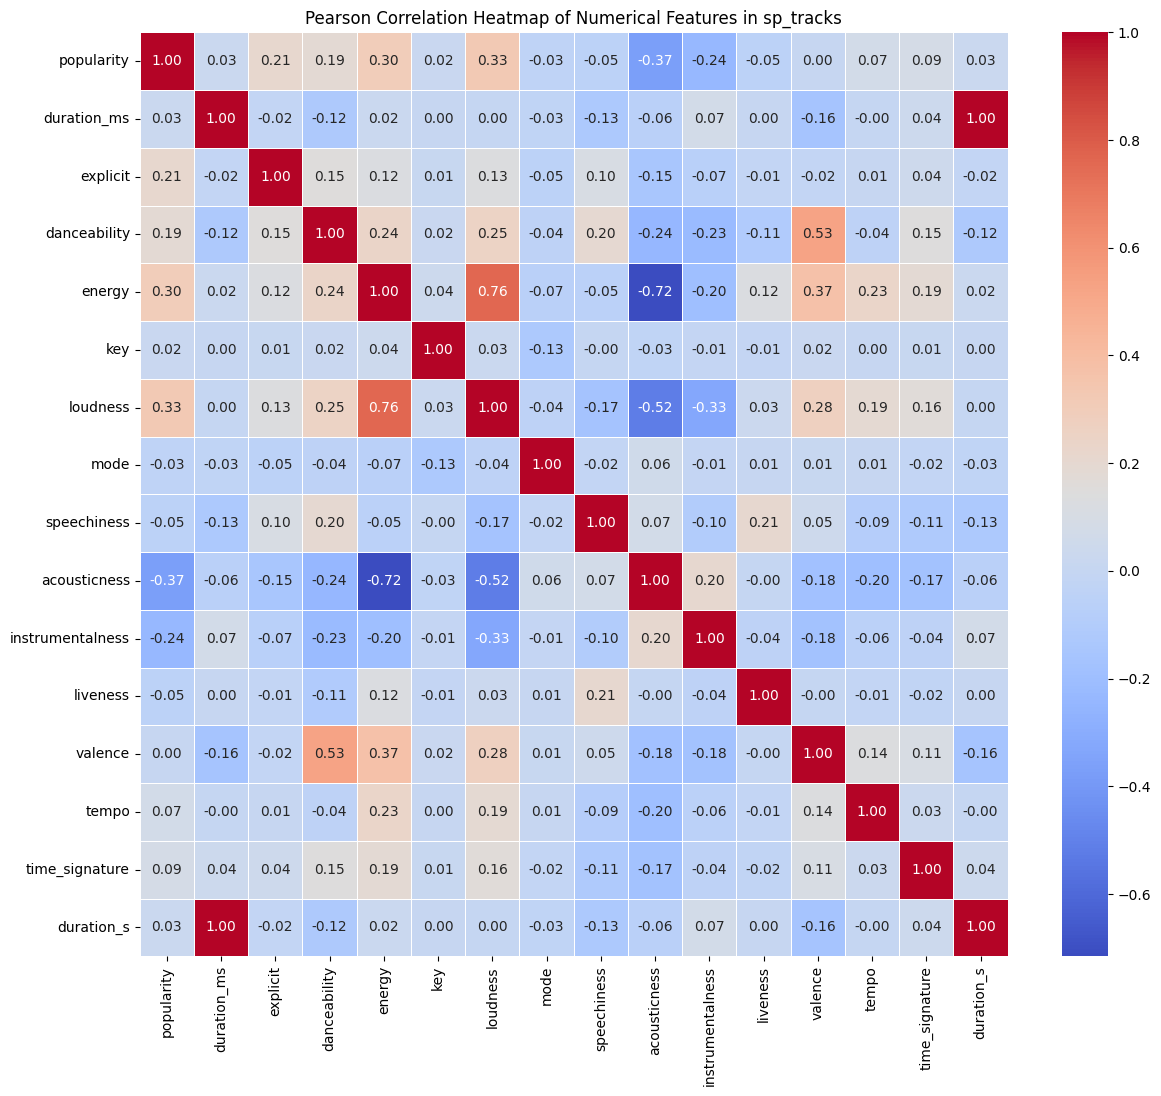

In [13]:
numerical_cols = sp_tracks.select_dtypes(include=[np.number]).columns
correlation_matrix = sp_tracks[numerical_cols].corr(method='pearson')

plt.figure(figsize=(14, 12))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Pearson Correlation Heatmap of Numerical Features in sp_tracks')
plt.show()

In [14]:
sp_tracks_sample = sp_tracks.sample(frac=0.04, random_state=42)
print(f"Original dataset shape: {sp_tracks.shape}")
print(f"Sampled dataset shape: {sp_tracks_sample.shape}")
display(sp_tracks_sample.head())

Original dataset shape: (586672, 20)
Sampled dataset shape: (23467, 20)


,id,name,popularity,duration_ms,explicit,artists,id_artists,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,duration_s
release_date,,,,,,,,,,,,,,,,,,,,
1985-01-01,0rTUAMd7huYjda84aceuzl,Дети проходных дворов,21,105015,0,['Kino'],['2jkl2xJVm71azWAgZKyf42'],0.890,0.6680,9,-10.044,0,0.0533,0.570,0.000002,0.0591,0.942,137.934,4,105.015
2017-08-25,4bMy8NjgkVHize43OSrChu,95,37,234800,0,['Picture This'],['7jLSEPYCYQ5ssWU3BICqrW'],0.663,0.5510,1,-6.445,1,0.0280,0.697,0.000000,0.1800,0.339,128.992,4,234.800
1992-01-01,4X1xn2bjxlaLbx6o3jSEXj,As almal ver is,10,147733,0,['Koos Du Plessis'],['4utxbudXUuseiCfVJ0B2xM'],0.376,0.0979,2,-18.280,1,0.0350,0.485,0.000577,0.1150,0.236,90.290,3,147.733
1969-01-01,3ZwzDf7V1xlAS9WWuviqIm,"Il tuo mondo (Nono, dobri moj nono)",29,194373,0,['Claudio Villa'],['2r4iOKmxTQU9s361Yt3gq1'],0.565,0.3270,5,-13.843,1,0.0295,0.781,0.000011,0.1310,0.556,103.256,3,194.373
2015-12-25,712Hktc9DnU5u9uOSn1q1Y,Bazaar - Official Sunburn Goa 2015 Anthem,55,172500,0,"['KSHMR', 'Marnik']","['2wX6xSig4Rig5kZU6ePlWe', '6S3KljEiIOWoLMUyZr...",0.582,0.9790,11,-2.492,0,0.0714,0.125,0.001520,0.3390,0.196,128.010,4,172.500


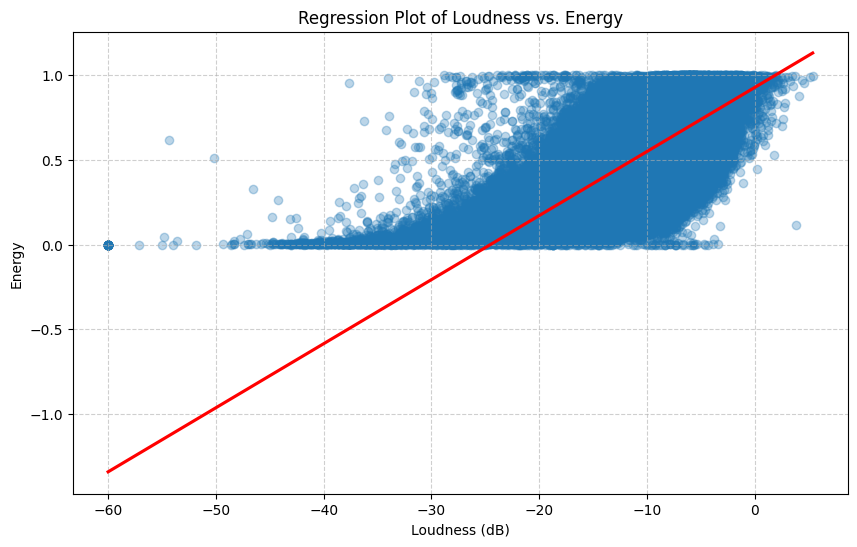

In [15]:
plt.figure(figsize=(10, 6))
sns.regplot(x='loudness', y='energy', data=sp_tracks, scatter_kws={'alpha':0.3}, line_kws={'color':'red'})
plt.title('Regression Plot of Loudness vs. Energy')
plt.xlabel('Loudness (dB)')
plt.ylabel('Energy')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

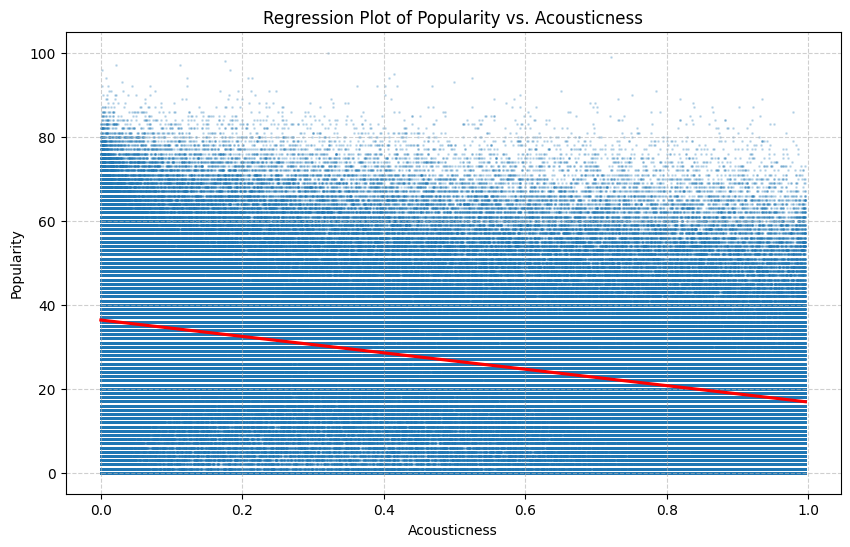

In [16]:
plt.figure(figsize=(10, 6))
sns.regplot(x='acousticness', y='popularity', data=sp_tracks, scatter_kws={'alpha':0.2, 's':1}, line_kws={'color':'red'})
plt.title('Regression Plot of Popularity vs. Acousticness')
plt.xlabel('Acousticness')
plt.ylabel('Popularity')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

In [17]:
sp_tracks['dates'] = sp_tracks.index
display(sp_tracks[['name', 'dates']].head())

,name,dates
release_date,,
1922-02-22,Carve,1922-02-22
1922-06-01,Capítulo 2.16 - Banquero Anarquista,1922-06-01
1922-03-21,Vivo para Quererte - Remasterizado,1922-03-21
1922-03-21,El Prisionero - Remasterizado,1922-03-21
1922-01-01,Lady of the Evening,1922-01-01


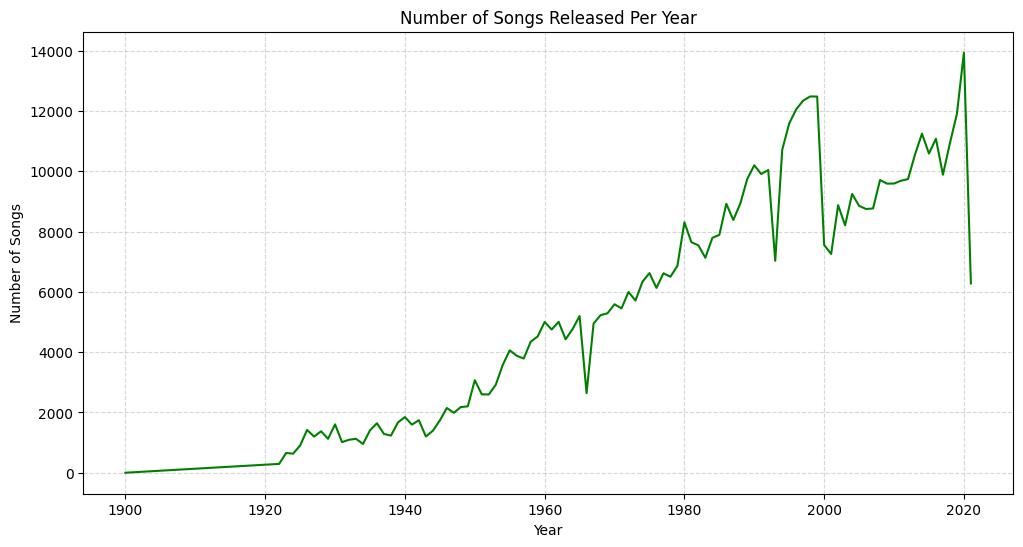

In [18]:
songs_per_year = sp_tracks['dates'].dt.year.value_counts().sort_index()

plt.figure(figsize=(12, 6))
sns.lineplot(x=songs_per_year.index, y=songs_per_year.values, color='green')
plt.title('Number of Songs Released Per Year')
plt.xlabel('Year')
plt.ylabel('Number of Songs')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

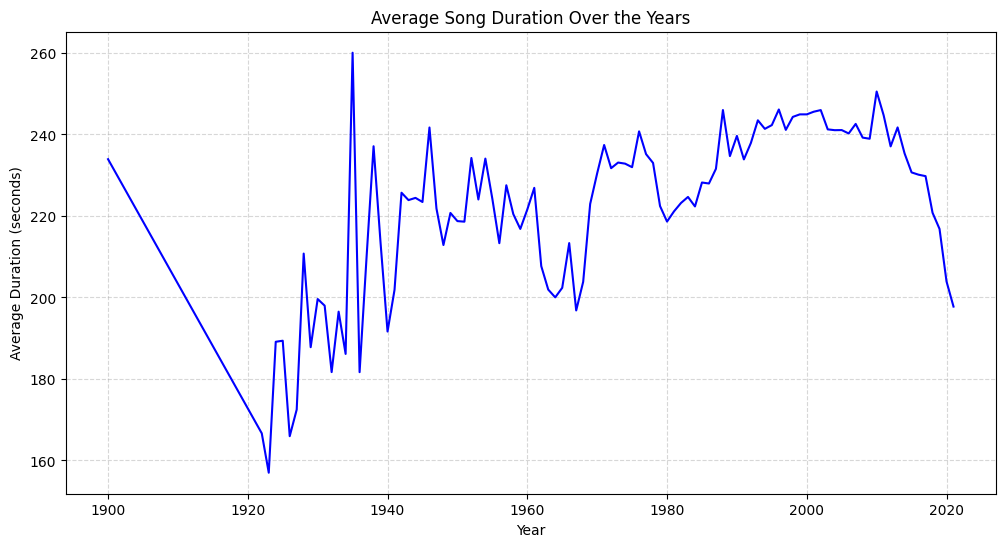

In [19]:
# Calculate average duration per year
duration_per_year = sp_tracks.groupby(sp_tracks['dates'].dt.year)['duration_s'].mean()

plt.figure(figsize=(12, 6))
sns.lineplot(x=duration_per_year.index, y=duration_per_year.values, color='blue')
plt.title('Average Song Duration Over the Years')
plt.xlabel('Year')
plt.ylabel('Average Duration (seconds)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

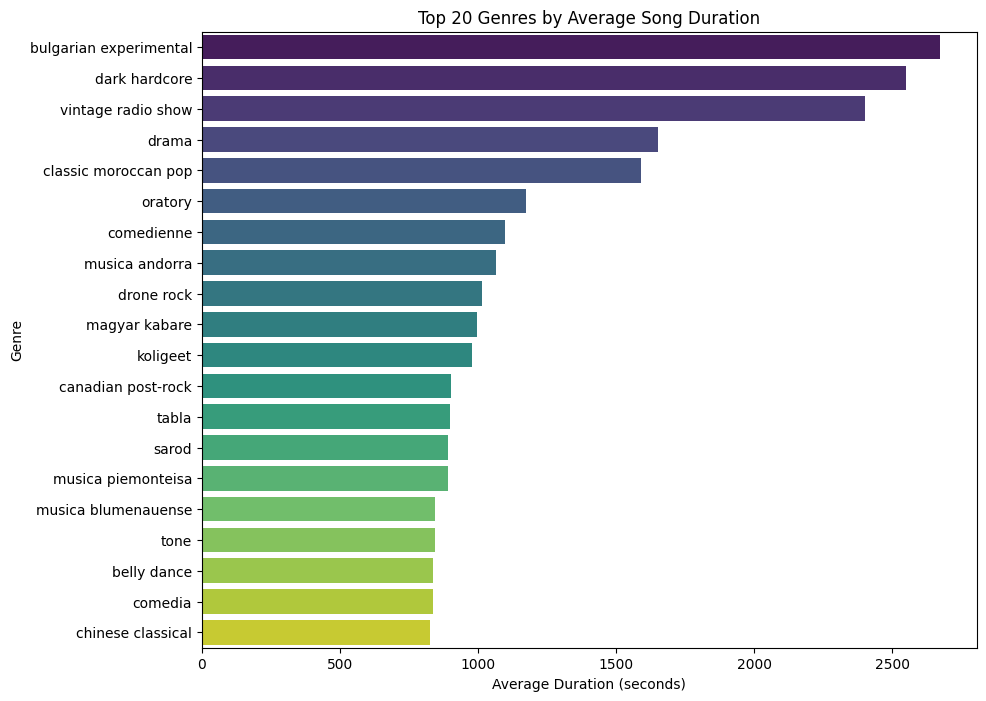

In [20]:
import ast

# Prepare artists data for merging
artists_genres = sp_artists[['id', 'genres']].copy()
artists_genres.rename(columns={'id': 'artist_id'}, inplace=True)

# Tracks has 'id_artists' as a string representation of a list. Parse and explode it.
tracks_exploded = sp_tracks.copy()
tracks_exploded['id_artists'] = tracks_exploded['id_artists'].apply(lambda x: ast.literal_eval(x) if isinstance(x, str) else x)
tracks_exploded = tracks_exploded.explode('id_artists')

# Merge tracks with artist genres
merged_df = tracks_exploded.merge(artists_genres, left_on='id_artists', right_on='artist_id')

# Genres are also string lists, parse and explode them
merged_df['genres'] = merged_df['genres'].apply(lambda x: ast.literal_eval(x) if isinstance(x, str) else x)
merged_df = merged_df.explode('genres')

# Drop null genres and calculate average duration per genre
genre_duration = merged_df.dropna(subset=['genres']).groupby('genres')['duration_s'].mean().sort_values(ascending=False)

# Plotting the top 20 genres by duration for clarity
plt.figure(figsize=(10, 8))
sns.barplot(x=genre_duration.head(20).values, y=genre_duration.head(20).index, hue=genre_duration.head(20).index, palette='viridis', legend=False)
plt.title('Top 20 Genres by Average Song Duration')
plt.xlabel('Average Duration (seconds)')
plt.ylabel('Genre')
plt.show()

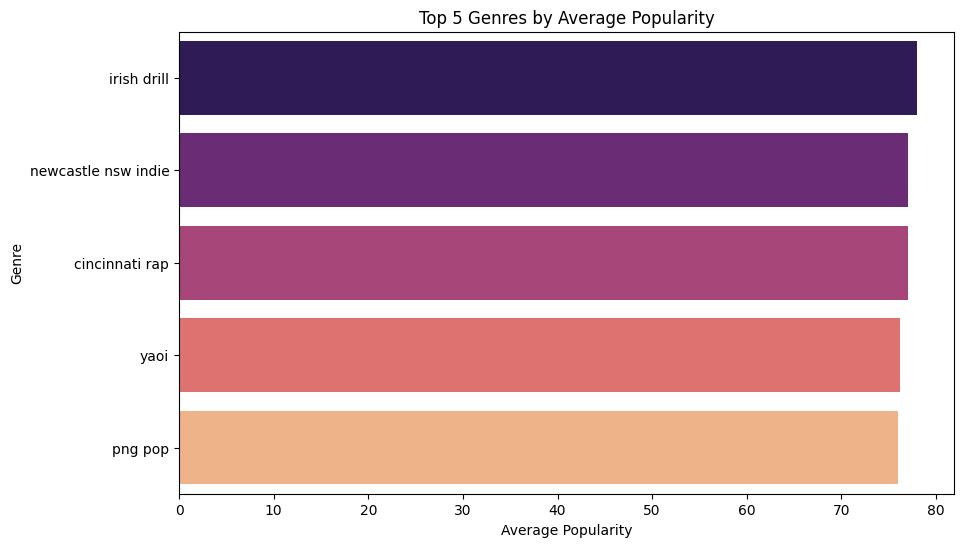

In [21]:
# Calculate average popularity per genre
genre_popularity = merged_df.dropna(subset=['genres']).groupby('genres')['popularity'].mean().sort_values(ascending=False).head(5)

# Plotting
plt.figure(figsize=(10, 6))
sns.barplot(x=genre_popularity.values, y=genre_popularity.index, hue=genre_popularity.index, palette='magma', legend=False)
plt.title('Top 5 Genres by Average Popularity')
plt.xlabel('Average Popularity')
plt.ylabel('Genre')
plt.show()